In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [3]:
file = pd.read_csv("height_weight_dataset.csv")

In [4]:
file.head()

,Height_cm,Weight_kg
0,175.0,55.6
1,168.6,45.0
2,176.5,47.9
3,185.2,60.0
4,167.7,47.7


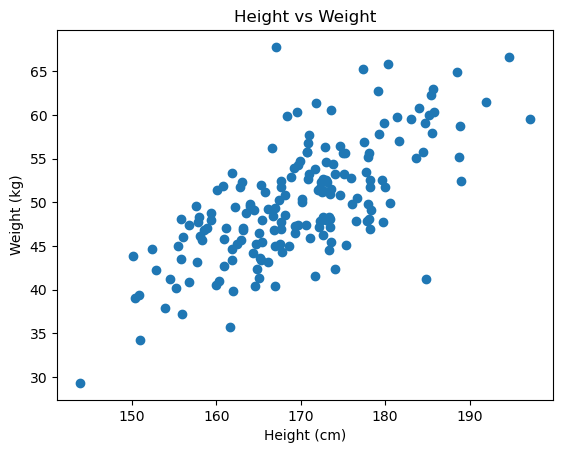

In [5]:
plt.scatter(file["Height_cm"],file["Weight_kg"])
plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.title("Height vs Weight")
plt.show()

In [6]:
file.corr()

,Height_cm,Weight_kg
Height_cm,1.000000,0.694144
Weight_kg,0.694144,1.000000


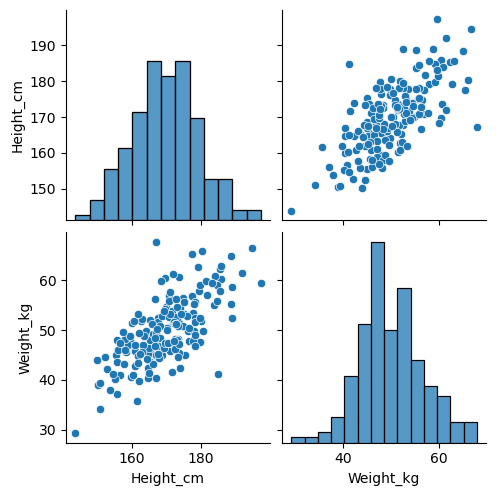

In [7]:
sns.pairplot(file)

<Axes: >

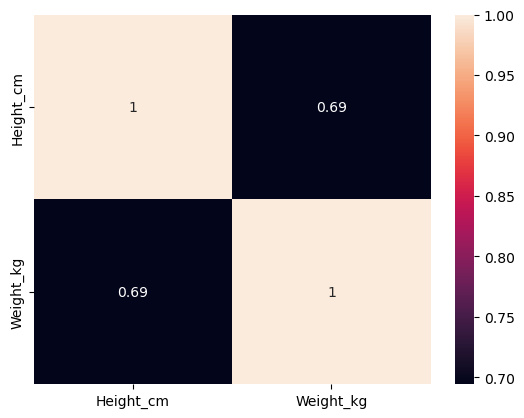

In [8]:
sns.heatmap(file.corr(), annot = True )

In [9]:
X = file[["Weight_kg"]]
y = file["Height_cm"]

In [10]:
X_train , X_test , y_train, y_test = train_test_split(X , y , test_size = 0.25)

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
# apply linear regression
regression = LinearRegression(n_jobs=-1)
regression.fit(X_train_scaled,y_train)

LinearRegression(n_jobs=-1)

In [13]:
regression.coef_

array([6.61087041])

In [14]:
regression.intercept_

170.4459259259259

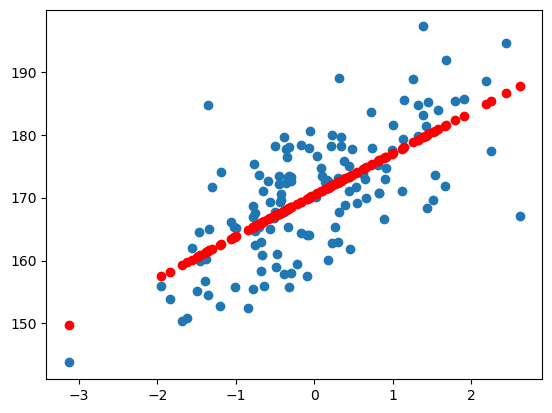

In [17]:
# plot the best fit line 
plt.scatter(X_train_scaled,y_train)
plt.scatter(X_train_scaled,regression.predict(X_train_scaled),color = "red")

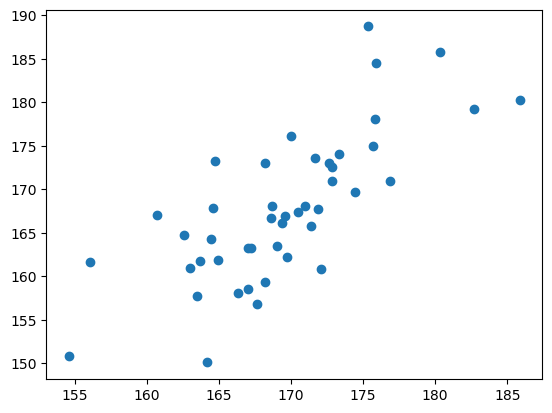

In [20]:
# prediction for test data 
y_pred = regression.predict(X_test_scaled)
plt.scatter(y_pred, y_test)

In [21]:
# performance metrics 
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score

In [23]:
mse = mean_squared_error(y_test , y_pred)
mse

34.38895535856755

In [24]:
mae = mean_absolute_error(y_test , y_pred)
mae

4.792560817512163

In [25]:
rmse = np.sqrt(mse)
rmse

5.864209695992082

In [26]:
# r2 score
score = r2_score(y_test , y_pred)
score

0.5100469495580331

In [27]:
# adjusted r2 score 
score_1 = 1 - (1 - score)*(len(y_test) - 1 )/(len(y_test) - X_test.shape[1] -1)
score_1

0.49865269257101064

OLS LINEAR REGRESSION

In [29]:
import statsmodels.api as sm

In [30]:
model = sm.OLS(y_train , X_train).fit()
prediction = model.predict(X_test)
print(prediction)


43     135.309643
87     149.041563
134    173.826002
138    186.553147
84     149.711412
6      201.959691
81     172.486303
86     209.997887
53     166.792580
0      186.218222
96     175.835552
127    148.036788
56     119.568175
136    165.787806
61     162.438557
177    186.888072
80     148.371713
114    170.141829
121    143.012915
52     156.744835
165    178.180026
26     156.744835
156    184.878523
57     165.452881
139    144.687540
116    181.864199
13     114.544302
21     173.156153
163    145.357389
69     163.443332
115    160.763933
33     160.763933
108    176.505401
93     162.103632
76     190.237321
178    168.467205
83     141.673216
158    154.400361
79     147.032014
101    171.481528
152    157.414684
147    158.754384
78     176.505401
54     220.715483
51     164.783031
dtype: float64


In [31]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:              Height_cm   R-squared (uncentered):                   0.989
Model:                            OLS   Adj. R-squared (uncentered):              0.989
Method:                 Least Squares   F-statistic:                          1.262e+04
Date:                Sat, 28 Feb 2026   Prob (F-statistic):                   1.88e-134
Time:                        00:06:06   Log-Likelihood:                         -577.94
No. Observations:                 135   AIC:                                      1158.
Df Residuals:                     134   BIC:                                      1161.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------